### Context

RNA sequencing (RNAseq) is one of the most commonly used techniques in life sciences and has been widely used in cancer research, drug development, and cancer diagnosis and prognosis. Sequencing the coding regions or the whole cancer transcriptome can provide valuable information about gene expression changes in tumors. Cancer RNA-Seq enables the detection of strand-specific information, an important component of gene regulation. Cancer transcriptome sequencing captures both coding and non-coding RNA and provides strand orientation for a complete view of expression dynamics.

### Objective

To use the Principal Component Analysis (PCA) technique to transform a large set of variables into a smaller one that still contains most of the information in the large set


### Key Concepts

- Applying PCA for dimensionality reduction
- Visualizing the data in the lower dimension


### Data Description

This collection of data is part of the RNA-Seq (HiSeq) PANCAN data set, it is a random extraction of gene expressions of patients having different types of tumor:

- BRCA
- KIRC
- COAD
- LUAD
- PRAD


Samples (instances) are stored row-wise. Variables (attributes) of each sample are RNA-Seq gene expression levels measured by illumina HiSeq platform.

A dummy name (gene_X) is given to each attribute.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.manifold import TSNE

In [2]:
data = pd.read_csv('data.csv', index_col=[0])
labels = pd.read_csv('labels.csv', index_col=[0])

In [3]:
data.head(3)

,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,gene_9,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0


In [4]:
data.shape

(801, 20531)

In [5]:
labels.head(3)

,Class
sample_0,PRAD
sample_1,LUAD
sample_2,PRAD


In [6]:
labels.shape

(801, 1)

### Combining the datasets

In [7]:
#frames = [labels, data]
df = pd.concat([labels, data], axis=1)
df.reset_index(drop=True, inplace=True)
df.shape

(801, 20532)

In [8]:
df.head(3)

,Class,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5,gene_6,gene_7,gene_8,...,gene_20521,gene_20522,gene_20523,gene_20524,gene_20525,gene_20526,gene_20527,gene_20528,gene_20529,gene_20530
0,PRAD,0.0,2.017209,3.265527,5.478487,10.431999,0.0,7.175175,0.591871,0.0,...,4.926711,8.210257,9.723516,7.220030,9.119813,12.003135,9.650743,8.921326,5.286759,0.0
1,LUAD,0.0,0.592732,1.588421,7.586157,9.623011,0.0,6.816049,0.000000,0.0,...,4.593372,7.323865,9.740931,6.256586,8.381612,12.674552,10.517059,9.397854,2.094168,0.0
2,PRAD,0.0,3.511759,4.327199,6.881787,9.870730,0.0,6.972130,0.452595,0.0,...,5.125213,8.127123,10.908640,5.401607,9.911597,9.045255,9.788359,10.090470,1.683023,0.0


## Data Preprocessing

In [9]:
# Scale the data except for the first column that is an object and not numerical
X = StandardScaler().fit_transform(df.iloc[:,1:].values)

In [10]:
X.shape

(801, 20531)

In [11]:
np.mean(X), np.std(X)

(1.4603746478980196e-18, 0.9934763587711302)

- The mean is nearly equal to zero and the variance is nearly 1 as we normalized the data.

## Applying PCA to dataset

In [12]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X)


In [13]:
pca_df = pd.DataFrame(
    data = pca_data,
    columns = ['Component 1', 'Component 2'])
pca_df.head()

,Component 1,Component 2
0,-57.446987,-95.410981
1,-16.919430,-0.732470
2,-70.345218,19.303326
3,-49.161591,9.227586
4,-18.132534,51.327797


In [14]:
print(
    "Explained variance per principal component: {:.5f} and {:.5f}"
    .format(
        pca.explained_variance_ratio_[0], 
        pca.explained_variance_ratio_[1]
    )
)

Explained variance per principal component: 0.10540 and 0.08754


In [15]:
# defining the targets
targets = list(df.Class.unique())
targets

['PRAD', 'LUAD', 'BRCA', 'KIRC', 'COAD']

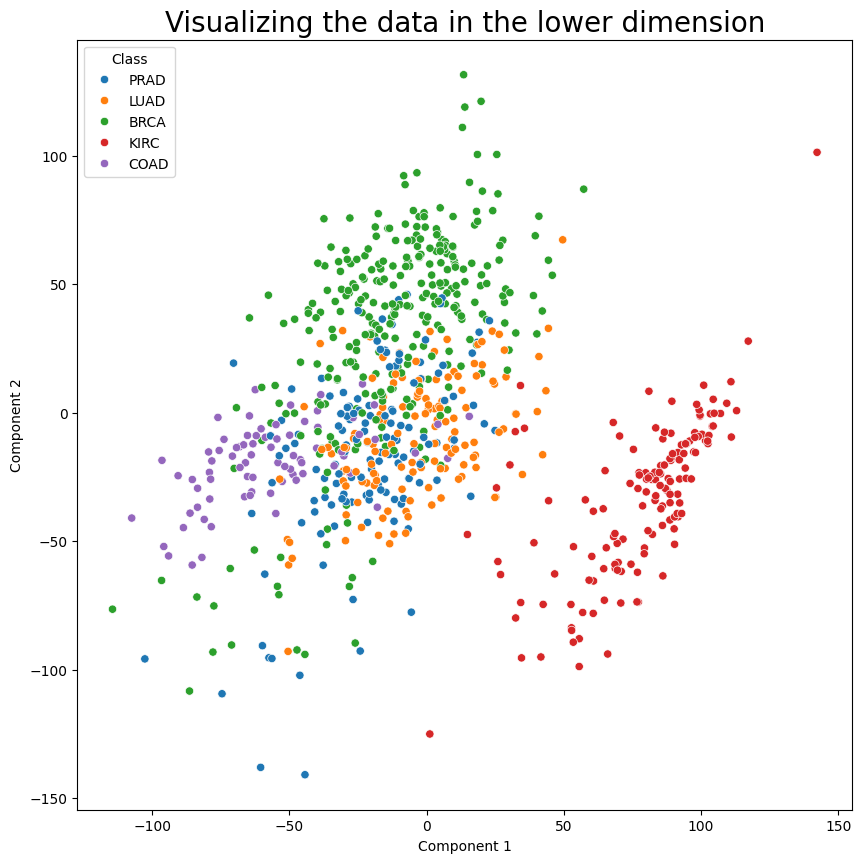

In [16]:
plt.figure(figsize=(10, 10))
sns.scatterplot(
    data=pca_df, 
    x="Component 1", 
    y="Component 2", hue=df.Class
)
plt.title("Visualizing the data in the lower dimension", fontsize=20)
plt.show()

- From the above plot, we can observe that the five classes (**PRAD**, **LUAD**, **BRCA**, **KIRC**, **COAD**), when projected to a two-dimensional space, can be linearly separable up to some extent.
- Other observations can be that the **KIRC** class is clearly separated out as compared to the other class.

## Add-on: Applying t-distributed Stochastic Neighbor Embedding (t-SNE)

**In the next few lines of code, we will be projecting the 20531-dimensional Cancer RNA-seq data to two-dimensions using t-SNE.**

- Original dimensions = 20531
- Dimensions after applying t-SNE = 2

**Note**: t-SNE is covered in the additional learning material of Week 2.

In [18]:
tsne = TSNE(n_components=2, random_state=1)
tsne_data = tsne.fit_transform(X)

In [19]:
tsne_df = pd.DataFrame(data=tsne_data,
                       columns = ['Component 1', 'Component 2'])
tsne_df.tail()

,Component 1,Component 2
796,9.342384,8.079128
797,-20.912342,-0.876169
798,-22.992805,15.324958
799,-5.181968,-21.392990
800,-9.007782,-21.403341


### Visualizing the data in the lower dimension

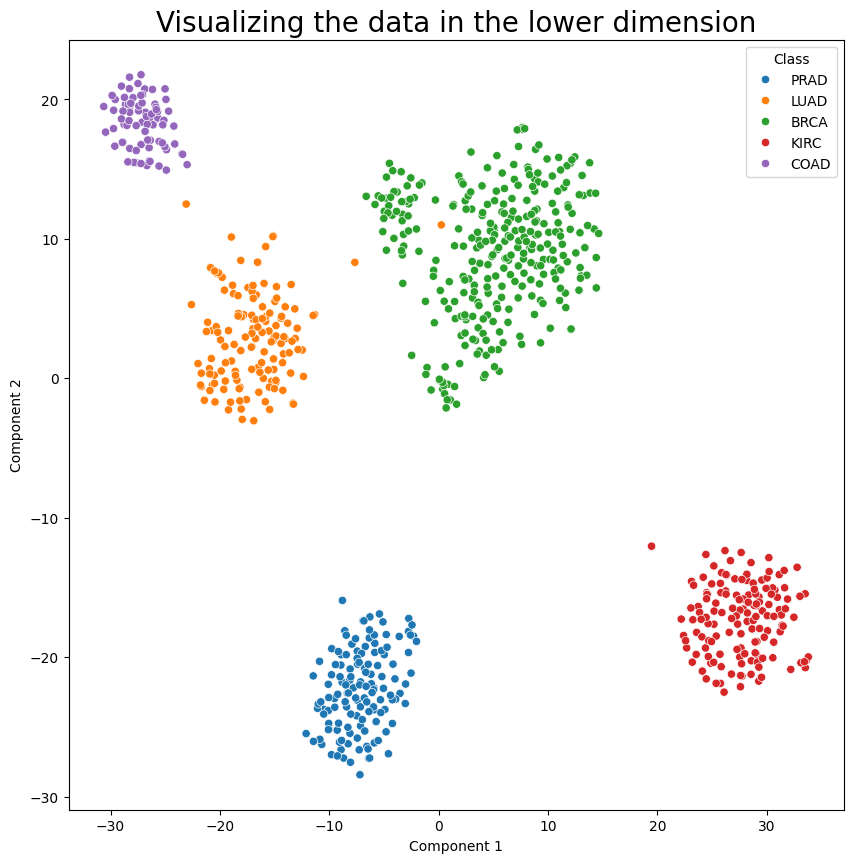

In [20]:
plt.figure(figsize=(10, 10))
sns.scatterplot(data=tsne_df, x="Component 1", y="Component 2", hue=df.Class)
plt.title("Visualizing the data in the lower dimension", fontsize=20)
plt.show()

### Changing Perplexity

Visualizing the lower dimensional representation of data for different values of perplexity


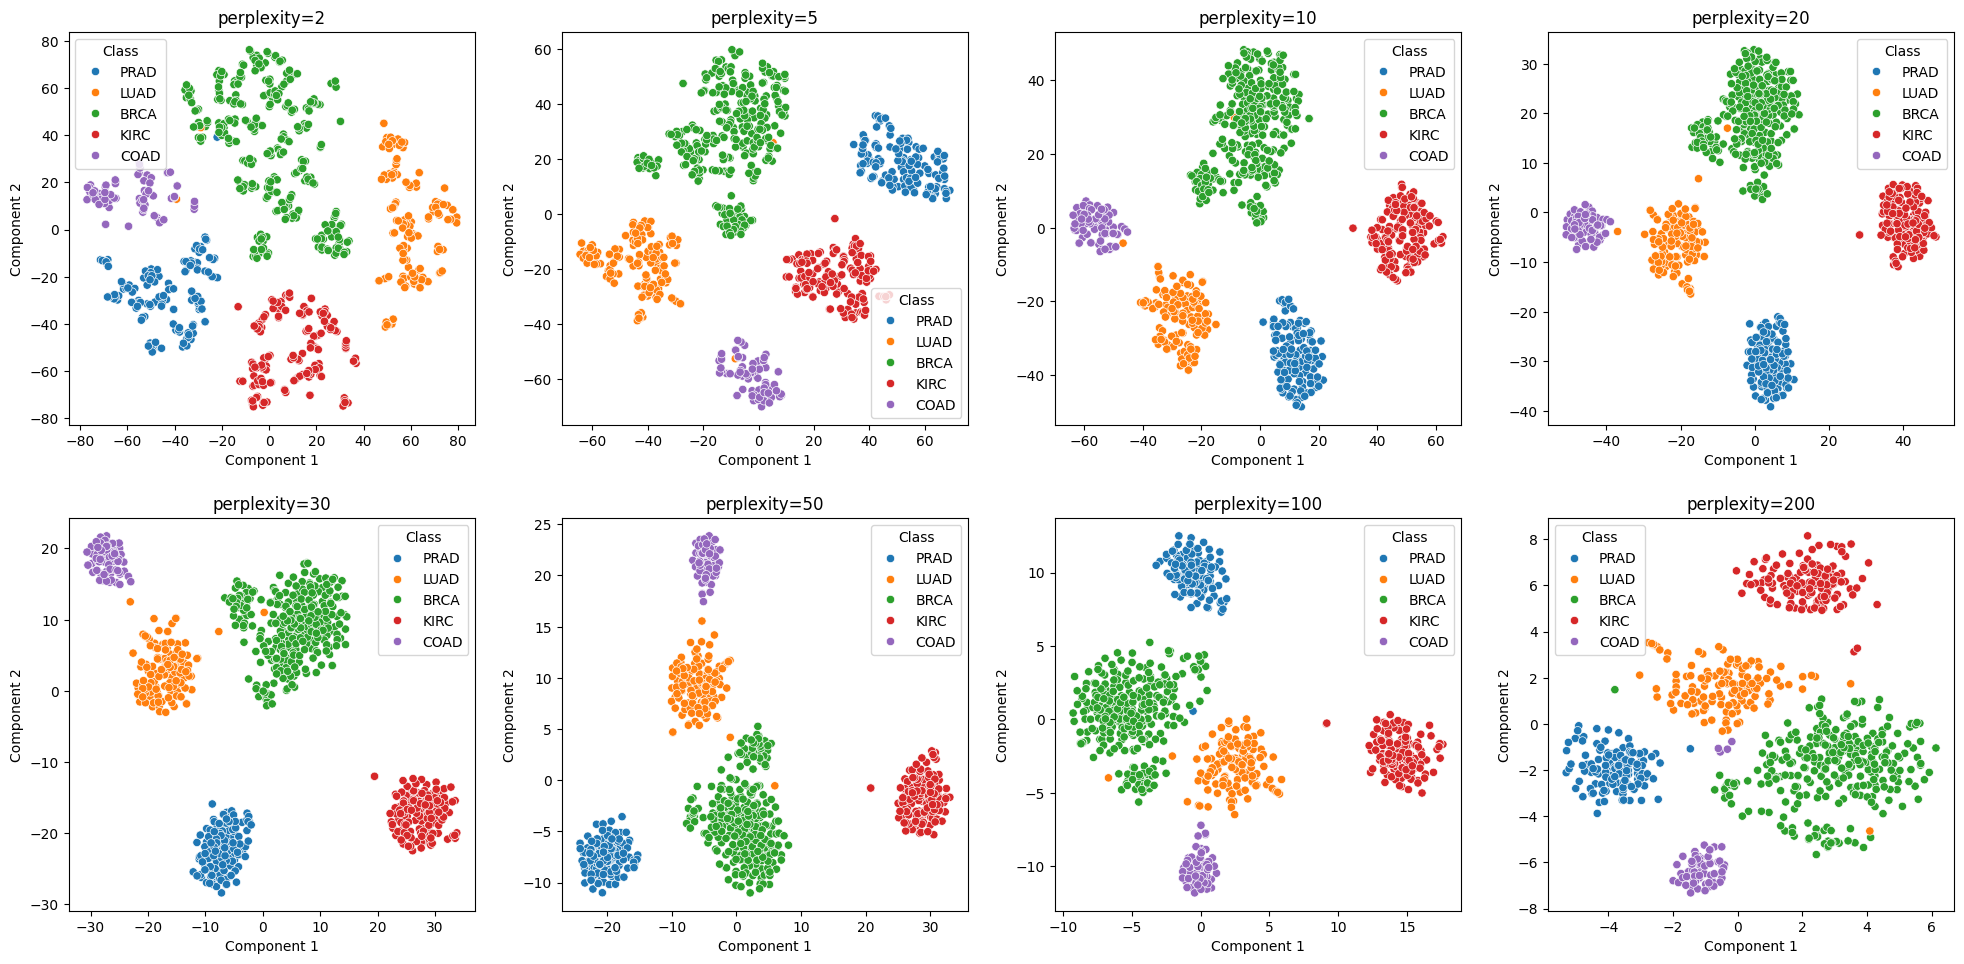

In [22]:
perplexity = [2, 5, 10, 20, 30, 50, 100, 200]

plt.figure(figsize=(20, 10))
print(
    "Visualizing the lower dimensional representation of data for different values of perplexity"
)

for i in range(len(perplexity)):
    tsne = TSNE(n_components=2, 
                perplexity=perplexity[i], 
                n_jobs=-2, 
                random_state=1)
    # n_jobs specifies the number of parallel jobs to run
    # -2 means using all processors except one
    X_red = tsne.fit_transform(X)

    red_data_df = pd.DataFrame(data=X_red, 
                               columns=["Component 1", "Component 2"])

    plt.subplot(2, int(len(perplexity) / 2), i + 1)

    plt.title("perplexity=" + str(perplexity[i]))
    sns.scatterplot(data=red_data_df, 
                    x="Component 1", 
                    y="Component 2", 
                    hue=df.Class),
    plt.tight_layout(pad=2)

**Observations**:

* With low perplexity value (2), data points are more scattered.
* With perplexity values ranging from 5 to 50, three distinct groups are clearly visible.
* With very high value of perplexity (100 and 200), the groups are still separable but slightly more spread out.